
# Lab 7: Fast Fourier Transform (FFT)

Santiago Andrés Angulo Toro CC 1001154362

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.fft import fft, fftfreq
import time as tm

Tasa de muestreo (sr): 44100 Hz
Número total de muestras (N): 152064
Duración del audio: 3.45 segundos


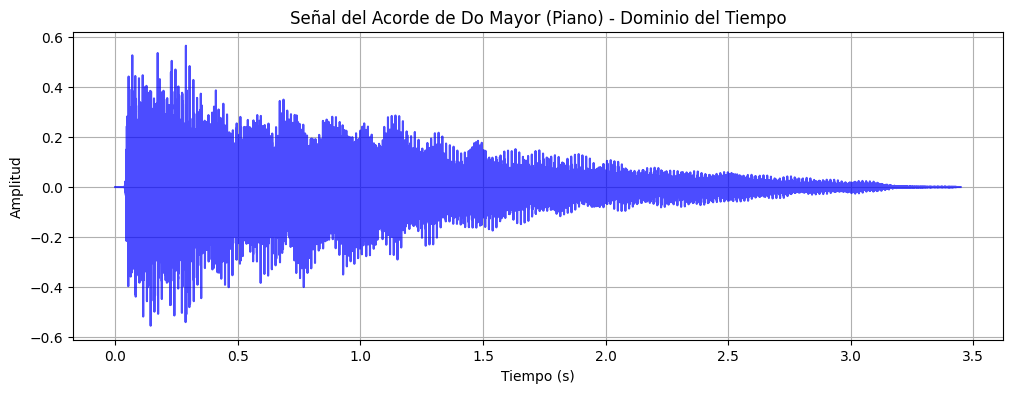

In [4]:
archivo = '/content/Nota_CM_piano.mp3'

# sr=None asegura que se mantenga la tasa de muestreo original (típicamente 44100 Hz)
y, sr = librosa.load(archivo, sr=None)

N = len(y)
duracion = N / sr
t = np.linspace(0, duracion, N)

print(f"Tasa de muestreo (sr): {sr} Hz")
print(f"Número total de muestras (N): {N}")
print(f"Duración del audio: {duracion:.2f} segundos")

# Graficar la señal en el dominio del tiempo
plt.figure(figsize=(12, 4))
plt.plot(t, y, color='blue', alpha=0.7)
plt.title("Señal del Acorde de Do Mayor (Piano) - Dominio del Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Tiempo de ejecución de la FFT (SciPy): 0.01129 segundos


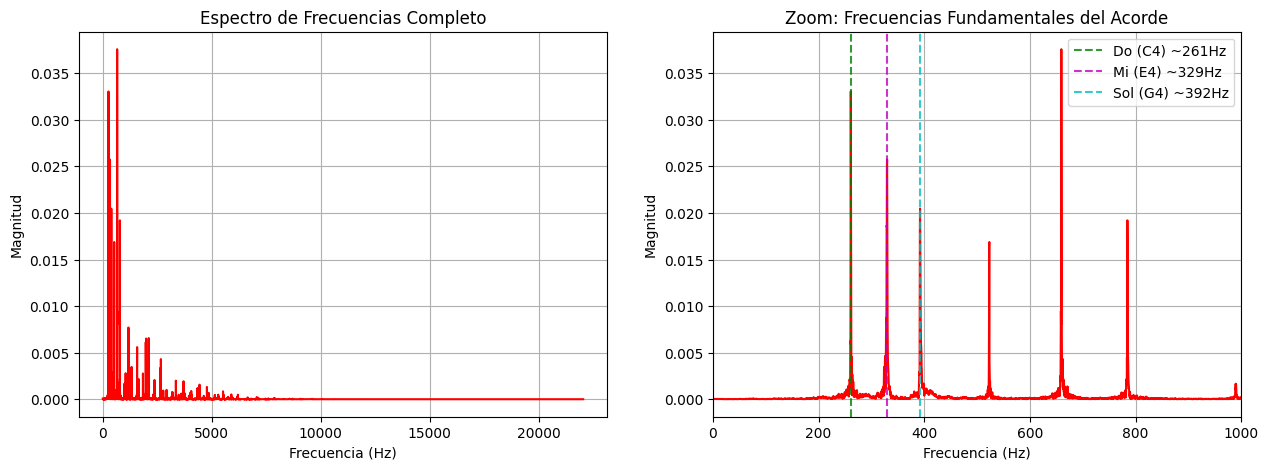

In [5]:
# 3. Cálculo de la FFT (SciPy)
t_ini_fft = tm.time()
yf = fft(y)
xf = fftfreq(N, 1/sr)
t_fin_fft = tm.time()

# Tomamos solo la mitad positiva del espectro
half_N = N // 2
xf_positivas = xf[:half_N]
yf_magnitud = np.abs(yf[:half_N]) * 2 / N  # Normalización de la amplitud

print(f"Tiempo de ejecución de la FFT (SciPy): {t_fin_fft - t_ini_fft:.5f} segundos")

# Graficar el espectro de frecuencias completo y con zoom
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Espectro completo
ax1.plot(xf_positivas, yf_magnitud, color='red')
ax1.set_title("Espectro de Frecuencias Completo")
ax1.set_xlabel("Frecuencia (Hz)")
ax1.set_ylabel("Magnitud")
ax1.grid(True)

# Zoom en las frecuencias fundamentales del piano (0 a 1000 Hz)
ax2.plot(xf_positivas, yf_magnitud, color='red')
ax2.set_xlim(0, 1000)
ax2.set_title("Zoom: Frecuencias Fundamentales del Acorde")
ax2.set_xlabel("Frecuencia (Hz)")
ax2.set_ylabel("Magnitud")

# Marco las frecuencias teóricas esperadas para inspección visual
notas_esperadas = [261.63, 329.63, 392.00]
colores = ['g', 'm', 'c']
etiquetas = ['Do (C4) ~261Hz', 'Mi (E4) ~329Hz', 'Sol (G4) ~392Hz']

for freq, col, etiq in zip(notas_esperadas, colores, etiquetas):
    ax2.axvline(x=freq, color=col, linestyle='--', alpha=0.8, label=etiq)

ax2.legend()
ax2.grid(True)
plt.show()

--- COMPARATIVA DE RENDIMIENTO (1000 muestras) ---
Tiempo método Manual FT: 0.07000 segundos
Tiempo método Rápido FFT: 0.00027 segundos
Diferencia numérica máxima entre ambos métodos: 1.90e-06



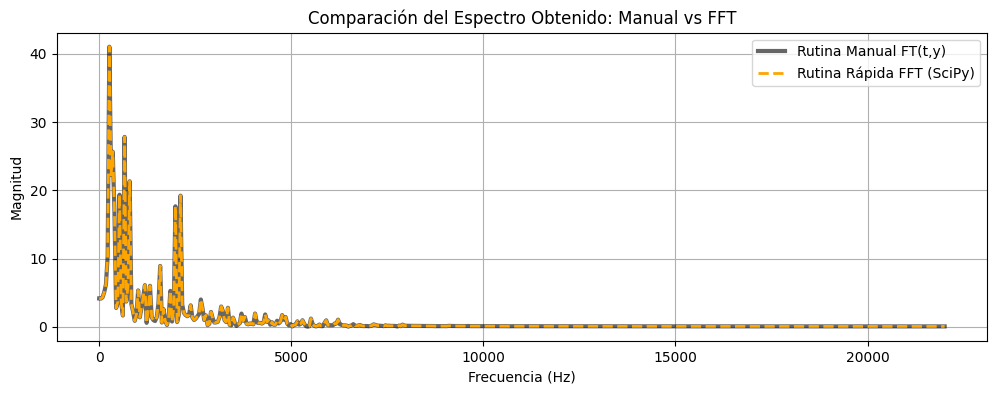

In [6]:
def FT(t, y):

    N = len(y)
    n = np.arange(N)
    k = n.reshape((N, 1))
    # Matriz de coeficientes de Fourier exponencial
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, y)

# 5. Comparación en un segmento corto del audio
# Tomo una pequeña porción (ej. 1000 muestras) para evitar congelar el entorno
num_muestras_test = 1000
segmento_y = y[20000 : 20000 + num_muestras_test]
segmento_t = t[20000 : 20000 + num_muestras_test]

# A) Evaluación con la rutina manual FT(t, y)
t_start_manual = tm.time()
resultado_manual = FT(segmento_t, segmento_y)
t_end_manual = tm.time()

# B) Evaluación con la rutina rápida FFT
t_start_fast = tm.time()
resultado_fft = fft(segmento_y)
t_end_fast = tm.time()

# Cálculo de magnitudes del segmento para verificar igualdad física
mag_manual = np.abs(resultado_manual[:num_muestras_test//2])
mag_fft = np.abs(resultado_fft[:num_muestras_test//2])
freqs_test = fftfreq(num_muestras_test, 1/sr)[:num_muestras_test//2]

# Tiempos de cálculo
print(f"--- COMPARATIVA DE RENDIMIENTO ({num_muestras_test} muestras) ---")
print(f"Tiempo método Manual FT: {t_end_manual - t_start_manual:.5f} segundos")
print(f"Tiempo método Rápido FFT: {t_end_fast - t_start_fast:.5f} segundos")
print(f"Diferencia numérica máxima entre ambos métodos: {np.max(np.abs(mag_manual - mag_fft)):.2e}\n")

# Graficar la comparación de resultados espectrales
plt.figure(figsize=(12, 4))
plt.plot(freqs_test, mag_manual, label="Rutina Manual FT(t,y)", color='black', linewidth=3, alpha=0.6)
plt.plot(freqs_test, mag_fft, label="Rutina Rápida FFT (SciPy)", color='orange', linestyle='--', linewidth=2)
plt.title("Comparación del Espectro Obtenido: Manual vs FFT")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend()
plt.grid(True)
plt.show()